# ReturnSense
A machine learning pipeline to analyze e-commerce return data and uncover hidden patterns behind customer returns. It transforms unstructured return reasons into structured insights that businesses can use to reduce return rates and improve customer satisfaction.

### 🎯 Core Capabilities
*   **Semantic Clustering**: Maps raw comments into distinct logical problem areas.
*   **Linguistic Normalization**: Uses NLTK lemmatization to collapse complex word variations.
*   **Automated Theme Labeling**: Mathematically derives human-readable titles for every discovered cluster.
*   **Actionable Analytics**: Quantifies the business impact for each identified issue.


## 1. Setup & Configuration
Select the dataset mode ('amazon_electronics', 'clothing_retail', or 'google_apps') and initialize the required libraries.


In [42]:
# Options: 'amazon_electronics', 'clothing_retail', 'google_apps'
DATASET_MODE = 'amazon_electronics' 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import re
import textwrap
import nltk
from nltk.stem import WordNetLemmatizer

# Environment Setup
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
warnings = __import__('warnings')
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")

print(f"ReturnSense initialized in '{DATASET_MODE}' mode.")


ReturnSense initialized in 'amazon_electronics' mode.


## 2. Data Loading & Pre-Filtering
Map configurations based on the selected mode, load the CSV, and filter for negative sentiment.


In [43]:
# Configuration Mapping Logic
configs = {
    'amazon_electronics': {
        'path': 'Dataset/1429_1.csv',
        'text_col': 'reviews.text',
        'rank_col': 'reviews.rating',
        'filter_op': lambda df: df[pd.to_numeric(df['reviews.rating'], errors='coerce') <= 2],
        'extra_stops': ['tablet', 'amazon', 'device', 'kindle', 'fire', 'product', 'item']
    },
    'clothing_retail': {
        'path': 'Dataset/Womens Clothing E-Commerce Reviews.csv',
        'text_col': 'Review Text',
        'rank_col': 'Rating',
        'filter_op': lambda df: df[df['Rating'] <= 2],
        'extra_stops': ['dress', 'shirt', 'top', 'fabric', 'clothing', 'retailer', 'store']
    },
    'google_apps': {
        'path': 'Dataset/googleplaystore_user_reviews.csv',
        'text_col': 'Translated_Review',
        'rank_col': 'Sentiment',
        'filter_op': lambda df: df[df['Sentiment'] == 'Negative'],
        'extra_stops': ['app', 'game', 'application', 'google', 'play', 'android', 'phone']
    }
}

conf = configs[DATASET_MODE]

try:
    df_raw = pd.read_csv(conf['path'], low_memory=False)
    df_filtered = conf['filter_op'](df_raw)
    print(f"Loaded {len(df_raw)} records. Identified {len(df_filtered)} critical feedback points.")
except FileNotFoundError:
    print(f"'{conf['path']}' not found. Generating mock data for demonstration.")
    # Demo Data Generator
    demo_samples = {
        'amazon_electronics': ["battery dies fast", "screen cracked", "buttons stuck", "wont charge", "charging port broken"] * 10,
        'clothing_retail': ["too small", "shrank in wash", "itchy wool", "colors faded", "buttons fell off"] * 10,
        'google_apps': ["keeps crashing", "too many ads", "slow login", "stole my data", "laggy performance"] * 10
    }
    df_filtered = pd.DataFrame({conf['text_col']: demo_samples[DATASET_MODE]})

df = df_filtered.dropna(subset=[conf['text_col']]).copy()
print("Preview of processed feedback:")
display(df[[conf['text_col']]].head(3))


Loaded 34660 records. Identified 812 critical feedback points.
Preview of processed feedback:


,reviews.text
117,Didn't have some of the features I was looking...
126,i Bought this around black friday for $60 hopi...
169,I bought this tablet for my 4 year old daughte...


## 3. Text Lemmatization
Clean the raw text and apply NLTK lemmatization to extract the root form of each word (e.g., 'charging' -> 'charge').


In [44]:
lemmatizer = WordNetLemmatizer()

def return_sense_cleaner(text):
    # Basic cleaning
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Advanced root-word lemmatization
    words = text.split()
    return ' '.join([lemmatizer.lemmatize(w) for w in words])

df['normalized_text'] = df[conf['text_col']].apply(return_sense_cleaner)

# Speed optimization for large datasets
if len(df) > 5000:
    df = df.sample(5000, random_state=42)

print("Text normalization complete.")


Text normalization complete.


## 4. Feature Extraction
Convert the processed text into numerical features using TF-IDF and exclude domain-specific stop words.


In [45]:
# Industry-specific noise reduction
domain_stops = list(ENGLISH_STOP_WORDS.union(conf['extra_stops']).union([
    'wa', 'ha', 'thi', 'doe', 'really', 'good', 'great', 'nice', 'tried', 'better', 'best', 'just', 'like', 'time', 'got', 'buy', 'purchased', 'bought'
]))

# Initialize Vectorizer with N-Gram support
vectorizer = TfidfVectorizer(
    stop_words=domain_stops, 
    max_features=2000, 
    ngram_range=(1, 2), # Detect phrases up to 2 words
    min_df=5
)

X = vectorizer.fit_transform(df['normalized_text'])
print(f"TF-IDF Matrix Shape: {X.shape}")


TF-IDF Matrix Shape: (812, 645)


## 5. K-Means Clustering & Evaluation Metrics
Because this is an Unsupervised Learning model, traditional accuracy metrics (like F1-Score) do not apply. Instead, we evaluate the model's performance using the **Silhouette Score**. This metric mathematically validates how similar a review is to its own cluster compared to others. The algorithm iteratively tests different cluster counts and selects the `K` value that produces the highest global evaluation score.


In [46]:
scores = []
K_range = range(2, 9)
best_k = 2
max_s = -1

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    s = silhouette_score(X, labels)
    scores.append(s)
    if s > max_s:
        max_s, best_k = s, k

print(f"Optimal Number of Clusters Detected: {best_k}")
print(f"Model Evaluation Metric (Silhouette Score): {max_s:.4f}  [-1.0 to 1.0]\n")

# Final fit
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster_id'] = final_km.fit_predict(X)


Optimal Number of Clusters Detected: 8
Model Evaluation Metric (Silhouette Score): 0.0155  [-1.0 to 1.0]



## 6. Dimensionality Reduction (PCA)
Use PCA to project the high-dimensional TF-IDF vectors onto a 2D plane for plotting.


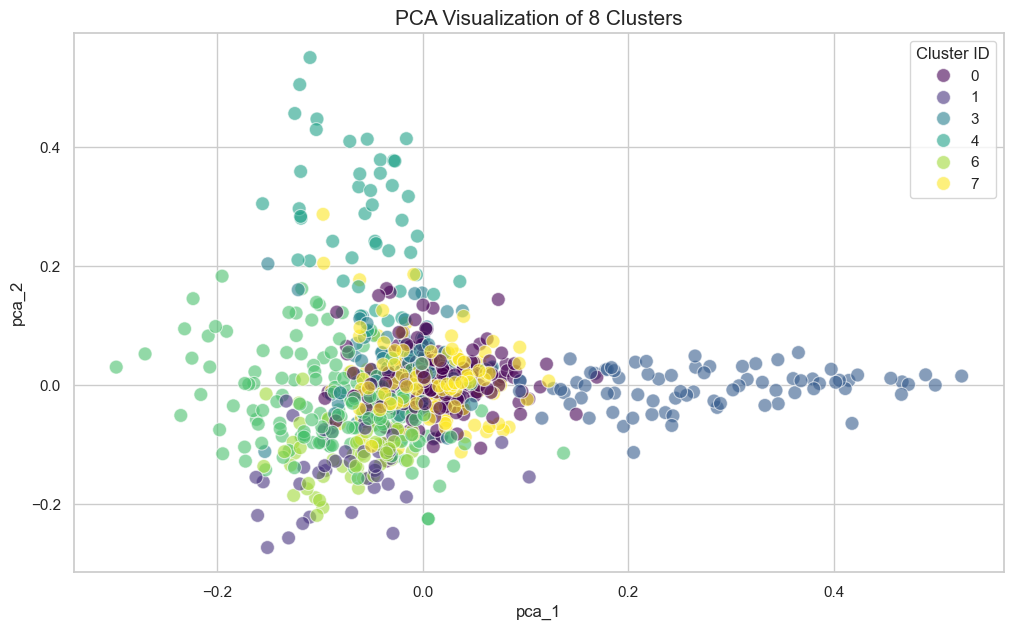

In [47]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X.toarray())
df['pca_1'], df['pca_2'] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(12, 7))
sns.scatterplot(x='pca_1', y='pca_2', hue='cluster_id', data=df, s=100, palette='viridis', alpha=0.6, edgecolor='w')
plt.title(f'PCA Visualization of {best_k} Clusters', fontsize=15)
plt.legend(title="Cluster ID", loc='best')
plt.show()


## 7. Cluster Analysis Summary
Extract top keywords for each cluster to identify central themes, and display corresponding dataset samples.


In [48]:
def extract_themes(model, vectorizer):
    centroids = model.cluster_centers_.argsort()[:, ::-1]
    terms = vectorizer.get_feature_names_out()
    themes = {}
    for i in range(model.n_clusters):
        top_words = [terms[ind] for ind in centroids[i, :15]]
        # Collision filtering: keep unique semantic labels
        unique_labels = []
        for w in top_words:
            if not any(w in u or u in w for u in unique_labels):
                unique_labels.append(w)
            if len(unique_labels) >= 3: break
        themes[i] = {"label": " & ".join(unique_labels).title(), "keywords": ", ".join(unique_labels[:5])}
    return themes

meta = extract_themes(final_km, vectorizer)

print(f"\n--- CLUSTER SUMMARY [{DATASET_MODE.upper()}] ---\n")
for cid, info in meta.items():
    c_df = df[df['cluster_id'] == cid]
    pct = (len(c_df) / len(df)) * 100
    print(f"[{info['label']}]")
    print(f"Size: {pct:.1f}%")
    print("-" * 40)
    
    examples = c_df[conf['text_col']].drop_duplicates().head(3).tolist()
    for i, ex in enumerate(examples, 1):
        clean_ex = str(ex).encode('ascii', 'ignore').decode('ascii')
        print(f"{i}. \"{textwrap.shorten(clean_ex, width=90, placeholder='...')}\"")
    print("\n")



--- CLUSTER SUMMARY [AMAZON_ELECTRONICS] ---

[Purchase & Returned & Day]
Size: 25.4%
----------------------------------------
1. "Didn't have some of the features I was looking for. Returned it the next day. May be..."
2. "I bought this tablet for my 4 year old daughter. Too many advertisements. I would..."
3. "fire tablet is very powerful for the size and does everything!"


[Kid & Friendly & Use]
Size: 5.0%
----------------------------------------
1. "If ads dont bother you, then this may be a decent device. Purchased this for my kid and..."
2. "Not Kid friendly at all. Purchased for little nephew. Wasn't given any info on it for..."
3. "Clunky and full of ads. Ok for my kids to use for games, but I wouldn't use this for..."


[Charge & Charging & Port]
Size: 9.7%
----------------------------------------
1. "Had it for about a week and now it won't take charge, tried new chargers and still not..."
2. "Will not seem to charge all the way and this is my 7th Kindlle."
3. "I have only 